<a href="https://colab.research.google.com/github/ShruthikaMurugesan/550k-Spotify-Songs-Audio-Lyrics-Genres/blob/main/EV_Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import random
import csv
from datetime import datetime, timedelta
import pandas as pd

random.seed(42)
pd.set_option("display.max_columns", None)

In [43]:
MANUFACTURERS = {
    "Tata":      ["Nexon EV Prime", "Tiago EV XZ", "Tigor EV Max", "Punch EV"],
    "Mahindra":  ["e2oPlus", "XUV400 EL", "XUV400 EC Pro", "eVerito"],
    "MG":        ["ZS EV Select", "Comet EV Play"],
    "BYD":       ["Atto 3", "Atto 3 Premium", "e6 Superior", "e6 Standard"],
    "Hyundai":   ["Kona Electric", "Kona Electric EX"],
}

FIRST_NAMES = ["Ramesh", "Amit", "Naveen", "Dinesh", "Manoj", "Ashok", "Nitin",
               "Sanjay", "Vijay", "Ravi", "Yogesh", "Sandeep", "Girish", "Anil",
               "Praveen", "Vikram", "Rakesh", "Suresh", "Deepak", "Rajesh",
               "Ajay", "Mohan", "Kiran", "Arun", "Vinay"]
LAST_NAMES = ["Iyer", "Malhotra", "Patel", "Chauhan", "Sharma", "Reddy",
              "Kumar", "Nair", "Yadav", "Rao", "Gupta", "Singh"]

FLEET_SIZE = 50

def build_fleet(n=FLEET_SIZE):
    fleet = []
    used_names = set()
    car_num = 1
    while len(fleet) < n:
        manufacturer = random.choice(list(MANUFACTURERS.keys()))
        model = random.choice(MANUFACTURERS[manufacturer])
        car_id = f"EV{car_num:03d}"
        while True:
            name = f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}"
            if name not in used_names:
                used_names.add(name)
                break
        fleet.append({
            "Car_ID": car_id,
            "EV_Name": model,
            "Manufacturer": manufacturer,
            "Driver_Name": name,
            "Range_Full_Charge_KM": random.choice([200, 220, 270, 300, 320, 380, 400]),
            "Safe_Speed": random.choice([60, 65, 70, 75, 80, 85]),
        })
        car_num += 1
    return fleet

FLEET = build_fleet()
pd.DataFrame(FLEET)

,Car_ID,EV_Name,Manufacturer,Driver_Name,Range_Full_Charge_KM,Safe_Speed
0,EV001,Nexon EV Prime,Tata,Arun Sharma,220,65
1,EV002,e2oPlus,Mahindra,Mohan Singh,320,60
2,EV003,Kona Electric EX,Hyundai,Amit Iyer,200,65
3,EV004,e2oPlus,Mahindra,Suresh Chauhan,380,85
4,EV005,Kona Electric EX,Hyundai,Sanjay Nair,320,70
5,EV006,Tiago EV XZ,Tata,Kiran Kumar,270,70
6,EV007,XUV400 EL,Mahindra,Vinay Reddy,200,60
7,EV008,Atto 3,BYD,Sandeep Reddy,320,70
8,EV009,Punch EV,Tata,Suresh Malhotra,300,60
9,EV010,Kona Electric EX,Hyundai,Ajay Rao,400,70


In [44]:
START_DATE = datetime(2025, 7, 1)
END_DATE   = datetime(2026, 6, 30)
STATUSES = ["Running", "Idle", "Garage", "Charging"]

def random_time_on_day(day):
    h = random.randint(0, 23)
    m = random.randint(0, 59)
    s = random.randint(0, 59)
    return day.replace(hour=h, minute=m, second=s)

def simulate_row(sno, car, day):
    status = random.choices(STATUSES, weights=[0.42, 0.23, 0.20, 0.15])[0]
    safe_speed = car["Safe_Speed"]
    working_condition = 1 if random.random() > 0.02 else 0  # 2% breakdown days

    if status == "Running" and working_condition:
        current_speed = random.randint(10, safe_speed + 25)
        overspeed = 1 if current_speed > safe_speed else 0
        distance = round(random.uniform(20, 320), 2)
        revenue = round(distance * random.uniform(12, 16), 2)
        battery = random.randint(15, 95)
        charging_hours = 0.0
        maintenance_cost = round(random.uniform(0, 150), 2) if random.random() < 0.05 else 0.0
    elif status == "Charging":
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(1, 40)
        charging_hours = round(random.uniform(0.5, 6), 2)
        maintenance_cost = 0.0
    elif status == "Garage":
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(5, 60)
        charging_hours = 0.0
        maintenance_cost = round(random.uniform(200, 3500), 2) if random.random() < 0.10 else 0.0
    else:  # Idle
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(10, 100)
        charging_hours = 0.0
        maintenance_cost = 0.0

    range_full = car["Range_Full_Charge_KM"]
    expected_remaining_distance = round(range_full * battery / 100, 1)
    ts = random_time_on_day(day)

    return {
        "S_No": sno,
        "Timestamp": ts.strftime("%d/%m/%y %H:%M:%S"),
        "Car_ID": car["Car_ID"],
        "EV_Name": car["EV_Name"],
        "Manufacturer": car["Manufacturer"],
        "Driver_Name": car["Driver_Name"],
        "Safe_Speed": safe_speed,
        "Current_Speed": current_speed,
        "Overspeed_Violation": overspeed,
        "Status": status,
        "Battery_Percentage": battery,
        "Range_Full_Charge_KM": range_full,
        "Expected_Remaining_Distance": expected_remaining_distance,
        "Charging_Time_Hours": charging_hours,
        "Distance_Covered_Today": distance,
        "Revenue_Generated_Today": revenue,
        "Working_Condition": working_condition,
        "Maintenance_Cost_Today": maintenance_cost,
    }

def generate_dataset(days_per_car=200):
    rows = []
    sno = 1
    total_days = (END_DATE - START_DATE).days
    for car in FLEET:
        chosen_days = sorted(random.sample(range(total_days + 1), min(days_per_car, total_days + 1)))
        for d in chosen_days:
            day = START_DATE + timedelta(days=d)
            rows.append(simulate_row(sno, car, day))
            sno += 1
    return rows

rows = generate_dataset()
df = pd.DataFrame(rows)
df.to_csv("ev_fleet_dataset.csv", index=False)
print(f"Generated {len(df)} rows for {len(FLEET)} vehicles across {len(MANUFACTURERS)} manufacturers.")
df.head()

Generated 10000 rows for 50 vehicles across 5 manufacturers.


,S_No,Timestamp,Car_ID,EV_Name,Manufacturer,Driver_Name,Safe_Speed,Current_Speed,Overspeed_Violation,Status,Battery_Percentage,Range_Full_Charge_KM,Expected_Remaining_Distance,Charging_Time_Hours,Distance_Covered_Today,Revenue_Generated_Today,Working_Condition,Maintenance_Cost_Today
0,1,02/07/25 02:42:58,EV001,Nexon EV Prime,Tata,Arun Sharma,65,78,1,Running,40,220,88.0,0.0,226.06,3562.94,1,0.0
1,2,05/07/25 10:25:44,EV001,Nexon EV Prime,Tata,Arun Sharma,65,25,0,Running,54,220,118.8,0.0,235.93,3114.58,1,0.0
2,3,07/07/25 09:25:35,EV001,Nexon EV Prime,Tata,Arun Sharma,65,63,0,Running,37,220,81.4,0.0,219.48,2966.62,1,0.0
3,4,08/07/25 18:38:41,EV001,Nexon EV Prime,Tata,Arun Sharma,65,0,0,Garage,18,220,39.6,0.0,0.00,0.00,1,0.0
4,5,10/07/25 09:32:42,EV001,Nexon EV Prime,Tata,Arun Sharma,65,37,0,Running,36,220,79.2,0.0,173.35,2630.58,1,0.0


In [45]:
START_DATE = datetime(2025, 7, 1)
END_DATE   = datetime(2026, 6, 30)
STATUSES = ["Running", "Idle", "Garage", "Charging"]

def random_time_on_day(day):
    h = random.randint(0, 23)
    m = random.randint(0, 59)
    s = random.randint(0, 59)
    return day.replace(hour=h, minute=m, second=s)

def simulate_row(sno, car, day):
    status = random.choices(STATUSES, weights=[0.42, 0.23, 0.20, 0.15])[0]
    safe_speed = car["Safe_Speed"]
    working_condition = 1 if random.random() > 0.02 else 0  # 2% breakdown days

    if status == "Running" and working_condition:
        current_speed = random.randint(10, safe_speed + 25)
        overspeed = 1 if current_speed > safe_speed else 0
        distance = round(random.uniform(20, 320), 2)
        revenue = round(distance * random.uniform(12, 16), 2)
        battery = random.randint(15, 95)
        charging_hours = 0.0
        maintenance_cost = round(random.uniform(0, 150), 2) if random.random() < 0.05 else 0.0
    elif status == "Charging":
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(1, 40)
        charging_hours = round(random.uniform(0.5, 6), 2)
        maintenance_cost = 0.0
    elif status == "Garage":
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(5, 60)
        charging_hours = 0.0
        maintenance_cost = round(random.uniform(200, 3500), 2) if random.random() < 0.10 else 0.0
    else:  # Idle
        current_speed = 0
        overspeed = 0
        distance = 0.0
        revenue = 0.0
        battery = random.randint(10, 100)
        charging_hours = 0.0
        maintenance_cost = 0.0

    range_full = car["Range_Full_Charge_KM"]
    expected_remaining_distance = round(range_full * battery / 100, 1)
    ts = random_time_on_day(day)

    return {
        "S_No": sno,
        "Timestamp": ts.strftime("%d/%m/%y %H:%M:%S"),
        "Car_ID": car["Car_ID"],
        "EV_Name": car["EV_Name"],
        "Manufacturer": car["Manufacturer"],
        "Driver_Name": car["Driver_Name"],
        "Current_Speed": current_speed,
        "Overspeed_Violation": overspeed,
        "Status": status,
        "Battery_Percentage": battery,
        "Range_Full_Charge_KM": range_full,
        "Expected_Remaining_Distance": expected_remaining_distance,
        "Charging_Time_Hours": charging_hours,
        "Distance_Covered_Today": distance,
        "Revenue_Generated_Today": revenue,
        "Working_Condition": working_condition,
        "Maintenance_Cost_Today": maintenance_cost,
    }

def generate_dataset(days_per_car=200):
    rows = []
    sno = 1
    total_days = (END_DATE - START_DATE).days
    for car in FLEET:
        chosen_days = sorted(random.sample(range(total_days + 1), min(days_per_car, total_days + 1)))
        for d in chosen_days:
            day = START_DATE + timedelta(days=d)
            rows.append(simulate_row(sno, car, day))
            sno += 1
    return rows

rows = generate_dataset()
df = pd.DataFrame(rows)
df.to_csv("ev_fleet_dataset.csv", index=False)
print(f"Generated {len(df)} rows for {len(FLEET)} vehicles across {len(MANUFACTURERS)} manufacturers.")
df.head()

Generated 10000 rows for 50 vehicles across 5 manufacturers.


,S_No,Timestamp,Car_ID,EV_Name,Manufacturer,Driver_Name,Current_Speed,Overspeed_Violation,Status,Battery_Percentage,Range_Full_Charge_KM,Expected_Remaining_Distance,Charging_Time_Hours,Distance_Covered_Today,Revenue_Generated_Today,Working_Condition,Maintenance_Cost_Today
0,1,01/07/25 16:52:34,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Charging,29,220,63.8,1.80,0.00,0.00,1,0.0
1,2,02/07/25 05:46:31,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Charging,1,220,2.2,3.41,0.00,0.00,1,0.0
2,3,04/07/25 13:00:02,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Garage,36,220,79.2,0.00,0.00,0.00,1,0.0
3,4,05/07/25 20:07:47,EV001,Nexon EV Prime,Tata,Arun Sharma,56,0,Running,68,220,149.6,0.00,150.54,2357.62,1,0.0
4,5,07/07/25 11:21:29,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Garage,37,220,81.4,0.00,0.00,0.00,1,0.0


In [46]:
df = pd.read_csv("ev_fleet_dataset.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%m/%y %H:%M:%S")
df["Month"] = df["Timestamp"].dt.to_period("M")
latest = df.sort_values("Timestamp").groupby("Car_ID").tail(1)
df.head()

,S_No,Timestamp,Car_ID,EV_Name,Manufacturer,Driver_Name,Current_Speed,Overspeed_Violation,Status,Battery_Percentage,Range_Full_Charge_KM,Expected_Remaining_Distance,Charging_Time_Hours,Distance_Covered_Today,Revenue_Generated_Today,Working_Condition,Maintenance_Cost_Today,Month
0,1,2025-07-01 16:52:34,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Charging,29,220,63.8,1.80,0.00,0.00,1,0.0,2025-07
1,2,2025-07-02 05:46:31,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Charging,1,220,2.2,3.41,0.00,0.00,1,0.0,2025-07
2,3,2025-07-04 13:00:02,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Garage,36,220,79.2,0.00,0.00,0.00,1,0.0,2025-07
3,4,2025-07-05 20:07:47,EV001,Nexon EV Prime,Tata,Arun Sharma,56,0,Running,68,220,149.6,0.00,150.54,2357.62,1,0.0,2025-07
4,5,2025-07-07 11:21:29,EV001,Nexon EV Prime,Tata,Arun Sharma,0,0,Garage,37,220,81.4,0.00,0.00,0.00,1,0.0,2025-07


In [47]:
print("Status counts (latest reading per car):")
display(latest["Status"].value_counts())

print("\nRoadworthy vs broken down (latest reading):")
display(latest["Working_Condition"].value_counts().rename({1: "Working", 0: "Broken down"}))

Status counts (latest reading per car):


,count
Status,
Running,20
Idle,11
Garage,11
Charging,8



Roadworthy vs broken down (latest reading):


,count
Working_Condition,
Working,50


In [48]:
garage_count = (latest["Status"] == "Garage").sum()
print(f"Vehicles currently in Garage: {garage_count}")

Vehicles currently in Garage: 11


In [49]:
charging_count = (latest["Status"] == "Charging").sum()
print(f"Vehicles currently Charging: {charging_count}")

Vehicles currently Charging: 8


In [50]:
running_count = (latest["Status"] == "Running").sum()
print(f"Vehicles currently Running: {running_count}")

Vehicles currently Running: 20


In [51]:
manu_counts = df.drop_duplicates("Car_ID").groupby("Manufacturer")["Car_ID"].count()
display(manu_counts)
print(f"Total distinct manufacturers: {df['Manufacturer'].nunique()}")

,Car_ID
Manufacturer,
BYD,8
Hyundai,12
MG,6
Mahindra,11
Tata,13


Total distinct manufacturers: 5


In [52]:
revenue_by_car_month = df.groupby(["Car_ID", "Month"])["Revenue_Generated_Today"].sum()
display(revenue_by_car_month.head(12))

revenue_pivot = df.pivot_table(index="Car_ID", columns="Month",
                                values="Revenue_Generated_Today", aggfunc="sum", fill_value=0)
revenue_pivot.head()

Car_ID  Month  
EV001   2025-07    13111.17
        2025-08    10994.34
        2025-09    11940.05
        2025-10     9370.16
        2025-11    15634.94
        2025-12    16038.77
        2026-01    21875.36
        2026-02    23338.89
        2026-03    20033.20
        2026-04    14167.95
        2026-05    16991.89
        2026-06    31101.42
Name: Revenue_Generated_Today, dtype: float64

Month,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
Car_ID,,,,,,,,,,,,
EV001,13111.17,10994.34,11940.05,9370.16,15634.94,16038.77,21875.36,23338.89,20033.20,14167.95,16991.89,31101.42
EV002,24195.88,12602.45,19992.90,10753.39,24256.52,29236.65,6757.48,13844.07,21433.59,17753.04,29296.57,27505.91
EV003,18504.51,15048.75,12926.38,16353.20,25710.05,17321.51,26724.61,3525.07,24716.11,13347.07,19394.33,29402.56
EV004,7595.79,26210.08,22923.75,15570.27,11442.04,13546.75,23592.98,9153.51,9670.08,14216.41,20671.09,13340.37
EV005,19848.07,11898.09,16636.96,8512.68,13509.51,23129.45,15088.79,19489.52,26353.21,19312.44,16672.10,11519.63


In [53]:
maint_by_car_month = df.groupby(["Car_ID", "Month"])["Maintenance_Cost_Today"].sum()
display(maint_by_car_month.head(12))

maint_pivot = df.pivot_table(index="Car_ID", columns="Month",
                              values="Maintenance_Cost_Today", aggfunc="sum", fill_value=0)
maint_pivot.head()

Car_ID  Month  
EV001   2025-07       0.00
        2025-08      78.81
        2025-09       0.00
        2025-10       0.00
        2025-11       0.00
        2025-12       0.00
        2026-01      60.15
        2026-02      23.80
        2026-03       0.00
        2026-04    3424.95
        2026-05    7044.22
        2026-06     289.38
Name: Maintenance_Cost_Today, dtype: float64

Month,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
Car_ID,,,,,,,,,,,,
EV001,0.00,78.81,0.00,0.00,0.0,0.00,60.15,23.8,0.00,3424.95,7044.22,289.38
EV002,0.00,1185.11,0.00,2033.11,0.0,122.94,0.25,0.0,2966.84,0.00,183.88,0.00
EV003,175.46,0.00,0.00,489.81,10.6,2534.82,270.56,0.0,0.00,0.00,0.00,0.00
EV004,1661.73,0.00,0.00,0.00,956.4,127.41,0.00,0.0,0.00,0.00,3222.72,0.00
EV005,0.00,0.00,3905.71,2724.98,0.0,0.00,3374.53,0.0,33.69,0.00,0.00,0.00


In [54]:
cars_with_multiple_drivers = df.groupby("Car_ID")["Driver_Name"].nunique()
drivers_with_multiple_cars = df.groupby("Driver_Name")["Car_ID"].nunique()

print(f"Cars mapped to more than 1 driver: {(cars_with_multiple_drivers > 1).sum()} (should be 0)")
print(f"Drivers mapped to more than 1 car: {(drivers_with_multiple_cars > 1).sum()} (should be 0)")

Cars mapped to more than 1 driver: 0 (should be 0)
Drivers mapped to more than 1 car: 0 (should be 0)


In [55]:
revenue_by_driver = df.groupby("Driver_Name")["Revenue_Generated_Today"].sum().sort_values()
print(f"Minimum revenue driver: {revenue_by_driver.index[0]} -> {revenue_by_driver.iloc[0]:.2f}")
print(f"Maximum revenue driver: {revenue_by_driver.index[-1]} -> {revenue_by_driver.iloc[-1]:.2f}")

revenue_by_driver.sort_values(ascending=False).head(10)

Minimum revenue driver: Vijay Patel -> 160938.75
Maximum revenue driver: Mohan Singh -> 237628.45


,Revenue_Generated_Today
Driver_Name,
Mohan Singh,237628.45
Vinay Reddy,232944.63
Vijay Gupta,231840.89
Amit Iyer,222974.15
Girish Kumar,216734.10
Ramesh Malhotra,216259.52
Naveen Chauhan,215368.62
Ashok Kumar,214999.20
Ashok Sharma,213879.76


In [56]:
violations_by_driver = df.groupby("Driver_Name")["Overspeed_Violation"].sum().sort_values(ascending=False)
print(f"Top offender: {violations_by_driver.index[0]} -> {violations_by_driver.iloc[0]} violations")
violations_by_driver.head(10)

Top offender: Vinay Reddy -> 36 violations


,Overspeed_Violation
Driver_Name,
Vinay Reddy,36
Naveen Chauhan,36
Naveen Singh,35
Suresh Malhotra,34
Vinay Iyer,33
Rajesh Reddy,31
Mohan Singh,30
Praveen Gupta,30
Ashok Kumar,30


In [57]:
df[["Car_ID", "Timestamp"]].head()

,Car_ID,Timestamp
0,EV001,2025-07-01 16:52:34
1,EV001,2025-07-02 05:46:31
2,EV001,2025-07-04 13:00:02
3,EV001,2025-07-05 20:07:47
4,EV001,2025-07-07 11:21:29


In [58]:
latest[["Car_ID", "Battery_Percentage", "Expected_Remaining_Distance"]].head(10)

,Car_ID,Battery_Percentage,Expected_Remaining_Distance
3199,EV016,95,361.0
2399,EV012,71,284.0
399,EV002,34,108.8
3799,EV019,10,30.0
9199,EV046,68,217.6
7799,EV039,16,64.0
6999,EV035,55,165.0
1799,EV009,34,102.0
999,EV005,60,192.0
2199,EV011,98,196.0


In [59]:
from google.colab import files
files.download("ev_fleet_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:

CHARGER_POWER_KW = 7.0
ELECTRICITY_RATE = 8.0

df["Charging_Cost_Today"] = 0.0
charging_mask = df["Status"] == "Charging"
df.loc[charging_mask, "Charging_Cost_Today"] = (
    df.loc[charging_mask, "Charging_Time_Hours"] * CHARGER_POWER_KW * ELECTRICITY_RATE
).round(2)

df[["Car_ID", "Status", "Charging_Time_Hours", "Charging_Cost_Today"]].head(10)

,Car_ID,Status,Charging_Time_Hours,Charging_Cost_Today
0,EV001,Charging,1.80,100.80
1,EV001,Charging,3.41,190.96
2,EV001,Garage,0.00,0.00
3,EV001,Running,0.00,0.00
4,EV001,Garage,0.00,0.00
5,EV001,Garage,0.00,0.00
6,EV001,Charging,1.06,59.36
7,EV001,Running,0.00,0.00
8,EV001,Running,0.00,0.00
9,EV001,Idle,0.00,0.00


In [61]:
charging_cost_by_car_month = df.groupby(["Car_ID", "Month"])["Charging_Cost_Today"].sum()
display(charging_cost_by_car_month.head(12))

charging_cost_pivot = df.pivot_table(
    index="Car_ID", columns="Month",
    values="Charging_Cost_Today", aggfunc="sum", fill_value=0
)
charging_cost_pivot.head()

Car_ID  Month  
EV001   2025-07     714.00
        2025-08     256.48
        2025-09       0.00
        2025-10     219.52
        2025-11     901.04
        2025-12    1238.72
        2026-01     767.76
        2026-02     918.40
        2026-03     358.40
        2026-04       0.00
        2026-05     280.56
        2026-06     335.44
Name: Charging_Cost_Today, dtype: float64

Month,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
Car_ID,,,,,,,,,,,,
EV001,714.00,256.48,0.00,219.52,901.04,1238.72,767.76,918.40,358.40,0.00,280.56,335.44
EV002,924.56,295.12,431.20,0.00,334.32,128.24,516.32,303.52,154.56,746.48,0.00,470.40
EV003,0.00,0.00,544.32,72.24,420.56,351.68,608.72,661.92,533.12,598.64,530.88,529.20
EV004,547.12,134.40,556.64,156.80,286.16,945.28,364.56,766.08,58.80,579.04,779.52,1233.12
EV005,320.88,1234.24,243.04,528.64,390.88,967.68,104.16,0.00,533.68,323.68,584.64,661.92


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
numeric_cols = [
    "Current_Speed", "Overspeed_Violation",
    "Battery_Percentage", "Range_Full_Charge_KM", "Expected_Remaining_Distance",
    "Charging_Time_Hours", "Distance_Covered_Today", "Revenue_Generated_Today",
    "Working_Condition", "Maintenance_Cost_Today", "Charging_Cost_Today"
]

corr_matrix = df[numeric_cols].corr()
corr_matrix

,Current_Speed,Overspeed_Violation,Battery_Percentage,Range_Full_Charge_KM,Expected_Remaining_Distance,Charging_Time_Hours,Distance_Covered_Today,Revenue_Generated_Today,Working_Condition,Maintenance_Cost_Today,Charging_Cost_Today
Current_Speed,1.000000,0.730820,0.262654,0.027832,0.253714,-0.255607,0.711190,0.707075,0.104490,-0.081777,-0.255607
Overspeed_Violation,0.730820,1.000000,0.131306,0.010590,0.126087,-0.133698,0.372606,0.371051,0.054655,-0.043007,-0.133698
Battery_Percentage,0.262654,0.131306,1.000000,-0.007220,0.915351,-0.355038,0.265198,0.264289,-0.006545,-0.054552,-0.355038
Range_Full_Charge_KM,0.027832,0.010590,-0.007220,1.000000,0.344153,-0.011173,0.008429,0.007657,0.012731,-0.001950,-0.011173
Expected_Remaining_Distance,0.253714,0.126087,0.915351,0.344153,1.000000,-0.327475,0.247427,0.246687,0.001087,-0.048880,-0.327475
Charging_Time_Hours,-0.255607,-0.133698,-0.355038,-0.011173,-0.327475,1.000000,-0.251451,-0.250126,-0.000261,-0.045806,1.000000
Distance_Covered_Today,0.711190,0.372606,0.265198,0.008429,0.247427,-0.251451,1.000000,0.994901,0.102791,-0.079969,-0.251451
Revenue_Generated_Today,0.707075,0.371051,0.264289,0.007657,0.246687,-0.250126,0.994901,1.000000,0.102249,-0.079485,-0.250126
Working_Condition,0.104490,0.054655,-0.006545,0.012731,0.001087,-0.000261,0.102791,0.102249,1.000000,0.004440,-0.000261
Maintenance_Cost_Today,-0.081777,-0.043007,-0.054552,-0.001950,-0.048880,-0.045806,-0.079969,-0.079485,0.004440,1.000000,-0.045806


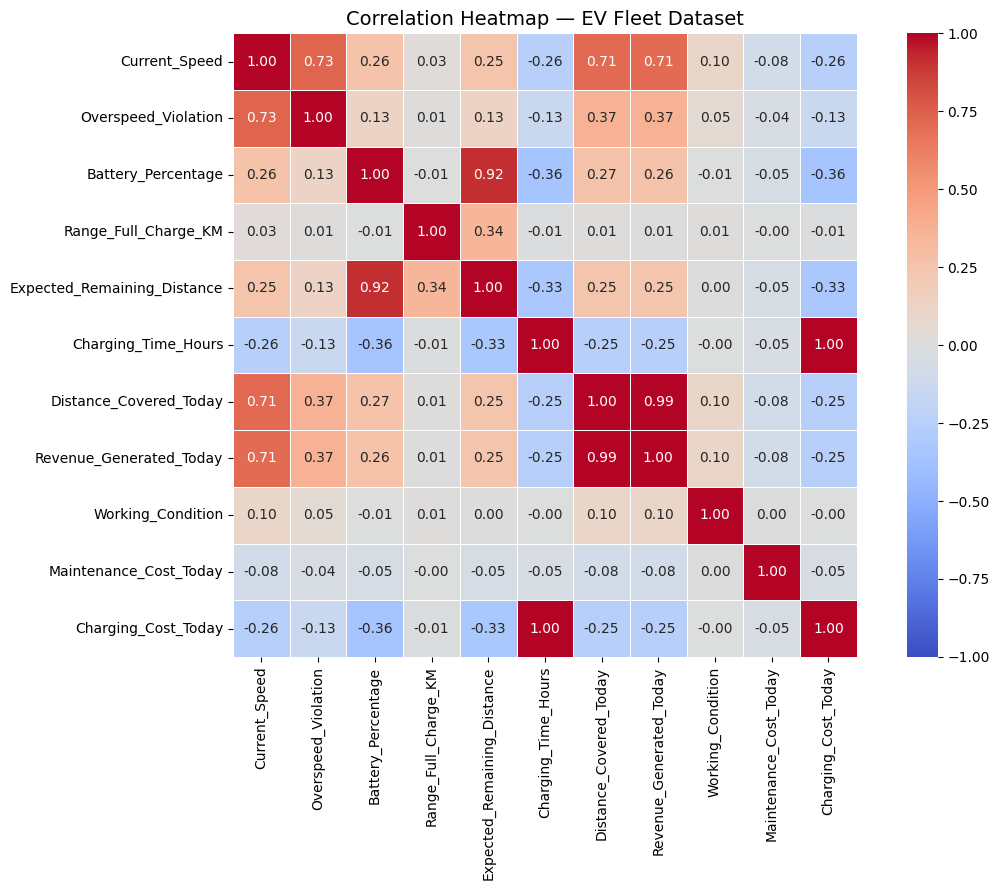

In [64]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap — EV Fleet Dataset", fontsize=14)
plt.tight_layout()
plt.show()

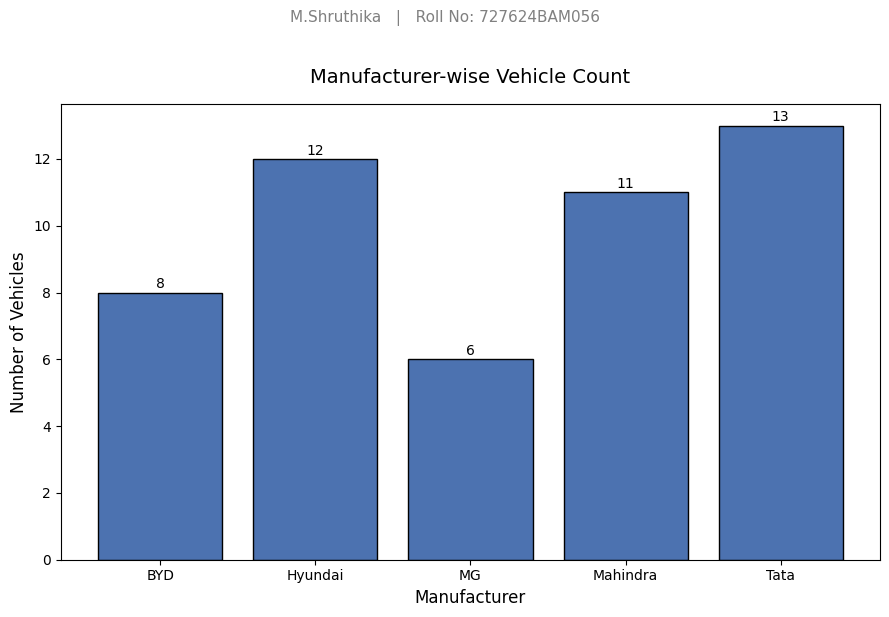

In [65]:
import matplotlib.pyplot as plt

STUDENT_NAME = "M.Shruthika"
ROLL_NO = "727624BAM056"

# Example: Manufacturer-wise vehicle count
manu_counts = df.drop_duplicates("Car_ID").groupby("Manufacturer")["Car_ID"].count()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(manu_counts.index, manu_counts.values, color="#4C72B0", edgecolor="black")

ax.set_xlabel("Manufacturer", fontsize=12)
ax.set_ylabel("Number of Vehicles", fontsize=12)
ax.set_title("Manufacturer-wise Vehicle Count", fontsize=14, pad=15)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=10)

fig.suptitle(f"{STUDENT_NAME}   |   Roll No: {ROLL_NO}", fontsize=11, y=1.02, color="gray")

plt.tight_layout()
plt.show()